In [22]:
1+1

2

In [23]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

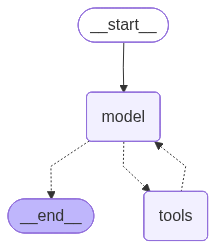

In [25]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model

def get_weather(city:str)-> str:
    ''' get the weather for a city'''
    return f"the weather in {city} is sunny"

model = init_chat_model(
    model="llama-3.3-70b-versatile",
    model_provider="groq"
)

agent=create_agent(
    model=model,
    tools=[get_weather],
    system_prompt="you are a helpful agent"
)

agent

In [26]:
agent.invoke({"messages":[{"role":"user","content":"what is the weather like in Delhi?"}]})

{'messages': [HumanMessage(content='what is the weather like in Delhi?', additional_kwargs={}, response_metadata={}, id='a8c96164-9278-4c61-baf5-91a9e15d6433'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'axp50qymq', 'function': {'arguments': '{"city":"Delhi"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 225, 'total_tokens': 240, 'completion_time': 0.050006339, 'completion_tokens_details': None, 'prompt_time': 0.036452876, 'prompt_tokens_details': None, 'queue_time': 0.161503383, 'total_time': 0.086459215}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d0b60-5d15-7881-aeb8-a6827797dd00-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Delhi'}, 'id': 'axp50qymq', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'i

<h1>Streaming - Invoke and Batch</h1>

In [27]:
model.invoke("write me an essay on porsche")

AIMessage(content="The Porsche brand is one of the most iconic and revered names in the automotive world. Founded in 1931 by Ferdinand Porsche, the company has a rich history of innovation, design, and performance. From its humble beginnings as a small consulting firm to its current status as a global luxury car manufacturer, Porsche has consistently pushed the boundaries of what is possible in the world of automobiles.\n\nOne of the key factors that has contributed to Porsche's success is its commitment to design and engineering excellence. The company's cars are known for their sleek, aerodynamic lines and exceptional handling and performance. The iconic 911, which was first introduced in 1963, is a perfect example of this. With its distinctive rear-engine design and curved silhouette, the 911 has become an instantly recognizable symbol of style and sophistication. Over the years, Porsche has continued to innovate and evolve its design language, introducing new models such as the Box

In [32]:
 for chunk in model.stream("write me an essay on porsche"):
    print(chunk.text,end="", flush =True)

The Porsche brand is synonymous with luxury, performance, and style. Founded in 1931 by Ferdinand Porsche, the company has a rich history that spans over nine decades. From its humble beginnings as a consulting firm to its current status as a leading manufacturer of high-performance sports cars, Porsche has consistently pushed the boundaries of innovation and excellence.

One of the most significant factors that contribute to Porsche's success is its commitment to performance. The company's early years were marked by the development of the Volkswagen Beetle, a people's car that was designed to be affordable and efficient. However, it was the introduction of the Porsche 356 in 1948 that truly put the company on the map. This sleek and powerful sports car was the first to bear the Porsche name and set the tone for the company's future endeavors. The 356 was followed by the iconic 911, which was introduced in 1963 and has since become one of the most recognizable and coveted sports cars i

flush=True ensures you see the Porsche essay being generated word-by-word in real-time, rather than waiting for all chunks to complete first.

<h3> output is streamed as it is generated from the model. No need to wait.</h3>

<h3>batch is a collection of independent requests to a model that can help in improving the performance and reducing the cost.  </h3>

In [39]:
res=model.batch(["why is porsche better than lambo?  is it for real?",
                 "why does porsche engine is placed behind?","which is better porsche vs ferrari"])

for i in res:
    print(i.text,end=" ")

The age-old debate: Porsche vs Lamborghini. Both are iconic luxury sports car brands with their own strengths and weaknesses. While opinions may vary, here's a balanced analysis of why some people might prefer Porsche over Lamborghini:

**Reasons why Porsche might be considered better:**

1. **Handling and Performance**: Porsche is known for its exceptional handling, thanks to its rear-engine layout and precise steering. Their cars are often praised for their agility, stability, and responsiveness, making them a joy to drive on twisty roads.
2. **Practicality and Daily Usability**: Porsches are generally more practical and comfortable for daily driving, with features like ample cargo space, comfortable seating, and advanced infotainment systems. They're also often more fuel-efficient than Lamborghinis.
3. **Reliability and Build Quality**: Porsche has a reputation for building solid, reliable cars with high-quality materials and attention to detail. This can lead to lower maintenance c

In [40]:
res=model.batch(["why is porsche better than lambo?  is it for real?",
                 "why does porsche engine is placed behind?","which is better porsche vs ferrari"], config={
                     'max_concurrency':5 # limited to 5 parallel calls
                 })

for i in res:
    print(i.text,end=" ")

The debate between Porsche and Lamborghini is often subjective and influenced by personal preferences, driving styles, and priorities. Both brands have their unique strengths and weaknesses. Here's a balanced comparison:

**Porsche's advantages:**

1. **Handling and agility**: Porsches are known for their exceptional handling, precision, and responsiveness. Their rear-engine layout and well-balanced weight distribution make them a joy to drive on twisty roads.
2. **Practicality and daily drivability**: Porsches are often more practical and comfortable for everyday driving, with features like more spacious interiors, better ergonomics, and more cargo space.
3. **Reliability and durability**: Porsche has a reputation for building robust and reliable cars, with many owners clocking high mileage without major issues.
4. **Racing heritage and track performance**: Porsche has a rich racing history, and their cars are often designed with track performance in mind. The 911, in particular, is a